In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

from low_rank_rnn.data import generate_perceptual_decision_making_trials
from low_rank_rnn.plotting import plot_first_perceptual_decision_making_trials


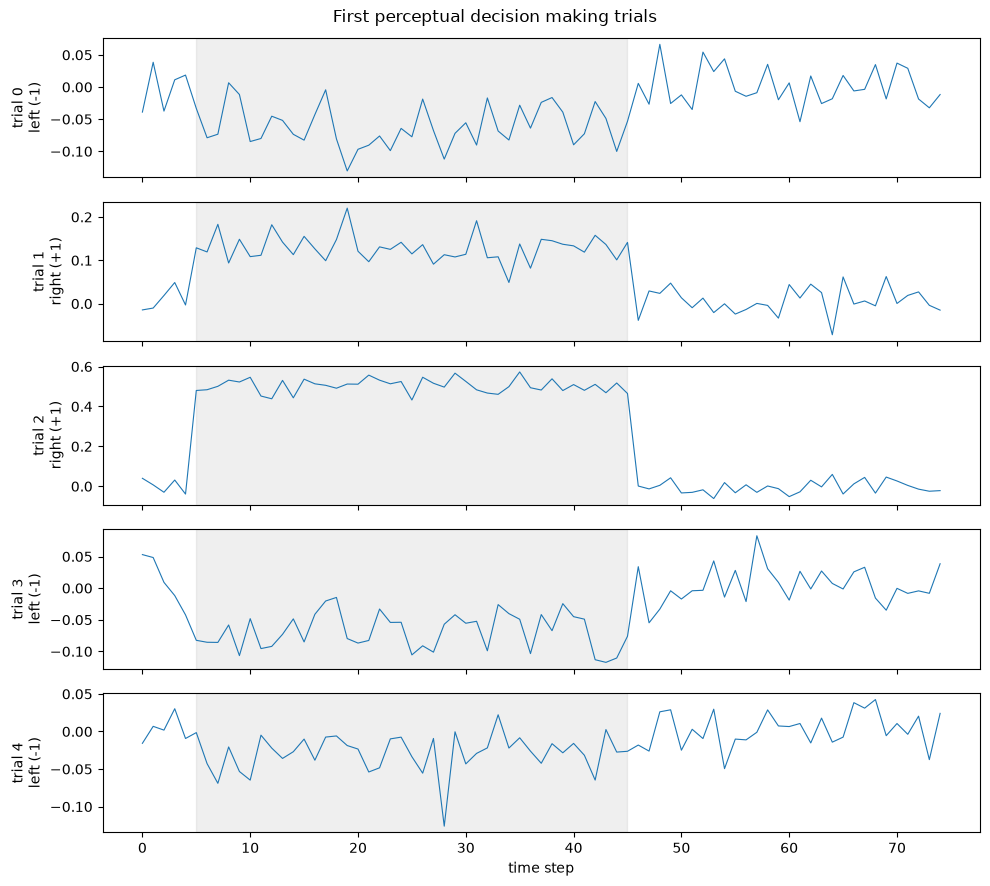

In [3]:
data, labels = generate_perceptual_decision_making_trials(num_trials=10)

fig, axes = plot_first_perceptual_decision_making_trials(
    data,
    labels,
    num_trials=5,
)
plt.show()


In [30]:
tau = 100 # ms
dt = 20 # ms

class LowRankRNN(nn.Module):
    def __init__(self, N: int):
        super().__init__()
        self.N = N

        # Initialize trainable parameters m, n
        self.m = nn.Parameter(torch.randn(N))
        self.n = nn.Parameter(torch.randn(N))
        
        # Initialize fixed parameters w, I
        self.register_buffer("I", torch.randn(N))
        self.register_buffer("w", 4.0 * torch.randn(N))


    def forward(self, u: torch.Tensor):
        batch_size, steps = u.shape
        x = u.new_zeros(batch_size, self.N)

        states, outputs = [], []
        for i in range(steps):
            # store state and output
            z = x @ self.w / self.N
            states.append(x)
            outputs.append(z)

            u_t = u[:, i]
            rates = torch.tanh(x) # (batch_size, N)

            # latent variable
            k = rates @ self.n / self.N # latent variable (batch_size,)
            recurrent = k[:, None] * self.m[None, :]
            external = u_t[:, None] * self.I[None, :]

            # euler step
            x_prime = -x + recurrent + external
            x = x + x_prime * (dt / tau)

        outputs = torch.stack(outputs, dim=1)   
        states = torch.stack(states, dim=1)
        
        return outputs, states

u, labels = generate_perceptual_decision_making_trials(num_trials=10)
model = LowRankRNN(N = 100)
outputs, states = model(torch.tensor(u, dtype=torch.float32))    
print(outputs.shape, states.shape)


torch.Size([10, 75]) torch.Size([10, 75, 100])
